# Assignment 4 Problem II: Helmholtz Steepest Descent #

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import dolfin as dl
import ufl
from hippylib import nb

import numpy as np
import logging


logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

np.random.seed(seed=42)

\begin{gather*}
  m(x,y) = \begin{cases}
    0.2 & \text{if} \; \sqrt{(x - 0.1)^2 + 2 (y + 0.2)^2} < 0.5 \\
    0 & \text{otherwise} \\
  \end{cases} \\
\end{gather*}


Refinement level 0; Number of mesh elements: 6402


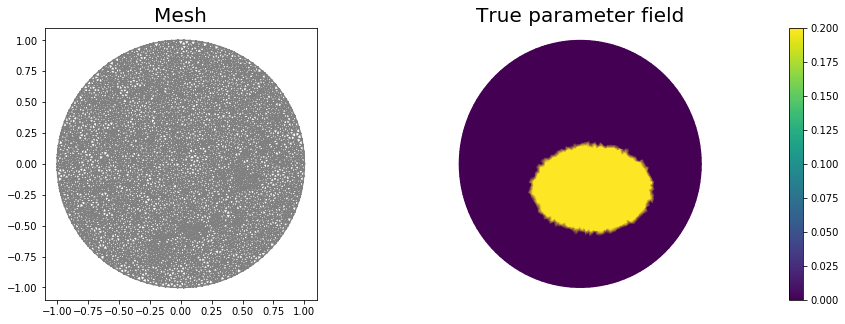

In [2]:
# create mesh and define function spaces
# mesh = dl.RectangleMesh(dl.Point(-1,-1),dl.Point(1,1), 32, 32)
mesh = dl.Mesh("circle.xml")
print("Refinement level 0; Number of mesh elements: {0}".format(mesh.num_cells()))

nrefinements = 0
for i in range(nrefinements):
    mesh = dl.refine(mesh)
    print("Refinement level {0}; Number of mesh elements: {1}".format(i+1, mesh.num_cells()))

Vm = dl.FunctionSpace(mesh, 'Lagrange', 1)
Vu = dl.FunctionSpace(mesh, 'Lagrange', 2)

# The true parameter, continuous and discretized/interpolated.
mtrue_cont = dl.Expression('0. + 0.2 * ((pow(x[0] - 0.1, 2) + 2*pow(x[1] + 0.2, 2)) < pow(0.5,2))', degree=5)
mtrue = dl.interpolate(mtrue_cont, Vm)

# plot
plt.figure(figsize=(15,5))
nb.plot(mesh, subplot_loc=121, mytitle="Mesh", show_axis='on')
nb.plot(mtrue, subplot_loc=122, mytitle="True parameter field")
plt.show()

The computational domain $\Omega = \{ x \in \mathbb{R}^2 \; | \; {\lVert x \rVert}^2 < 1 \}$ is the unit disc, $k_0 = 5$ is the wave number, and $\beta > 0$ is the regularization parameter. The incident wavefield $u^{\text{inc}}(x)$ is the superposition of three spherical waves with wave number $k_0$ generated by point-like sources. That is:

\begin{gather*}
  u^{\text{inc}}(x) = \sum\limits_{j=1}^{3} -e_i \frac{\cos (k_0 {\lvert x - x_i \rvert})}{4 \pi {\lvert x - x_i \rvert}} \\
\end{gather*}

where $x_i$ denote the locations of the three point-like sources and $e_i \sim N(0,1)$ are randomly chosen coefficients.

We will actually define $u_i$ for $\{1,2,3\}$ first, then multiply by the random number and combine in the next step.


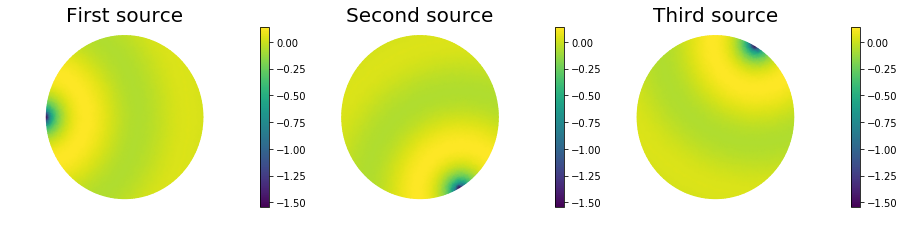

In [3]:
k0raw = 5.
k0sq = dl.Constant(k0raw*k0raw)
nsources = 3

def build_inc_wave(i):
    theta = -np.pi + 2*np.pi*i/nsources
    radius = 1.05
    xi = [radius*np.cos(theta), radius*np.sin(theta)]
    
    ei = np.random.normal()
    
    distance_source = dl.Expression("std::sqrt((x[0]-s0)*(x[0]-s0) + (x[1]-s1)*(x[1]-s1))",
                                    s0=xi[0], s1=xi[1], degree=1)
    u_i_exp = dl.Expression("-std::cos(k0*distance_source)/(4.*DOLFIN_PI*distance_source)",
                              k0=k0raw, distance_source=distance_source, degree=6)
    return dl.interpolate(u_i_exp, Vu)

# build_inc_wave(1)
u_is = [build_inc_wave(i) for i in range(nsources)]

# plot
plt.figure(figsize=(15,3.3))
nb.plot(u_is[0], subplot_loc=131, mytitle="First source")
nb.plot(u_is[1], subplot_loc=132, mytitle="Second source")
nb.plot(u_is[2], subplot_loc=133, mytitle="Third source")
plt.show()

## Source encoding

Source encoding is a common technique based on superposition of effects to reduce the computational cost of full-waveform inversion.

Simply put, source encoding exploits the linearity of the Helmholtz equation with respect to the source term and computes a single pressure field correspoding to the simulataneous exitation of all sources together. Here, we take the superimposed source $u_inc$ to be a random linear combination of all sources $u_i$. The weights $e_i$ of this linear combination are sampled from a i.i.d. Gaussian distribution. That is:

$$ u_{inc}(\boldsymbol{x}) = \sum_i e_i u_i(\boldsymbol{x}), \quad e_i \sim \mathcal{N}(0,1). $$

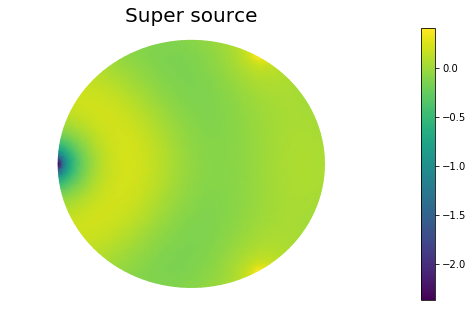

In [4]:
encoding = np.random.normal(size=nsources)

u_inc = dl.Function(Vu)

for i, u_i in enumerate(u_is):
    u_inc.vector().axpy(encoding[i], u_i.vector())
    
plt.figure(figsize=(7.5,5))
nb.plot(u_inc, mytitle="Super source")
plt.show()

In [5]:
# define trial/test/regular functions for parameter, state and adjoint
m, m_trial, m_test = dl.Function(Vm), dl.TrialFunction(Vm), dl.TestFunction(Vm)
u, u_trial, u_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)
p, p_trial, p_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)


The forward equation is the Helmholtz equation:

\begin{gather*}
  - \Delta u - k_0^2 (1 - \tanh(m)) u = k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}}, \quad \text{in} \; \Omega \\
  \frac{\partial u}{\partial n} = 0, \quad \text{on} \; \Gamma \\
\end{gather*}


in weak form:

\begin{gather*}
%  - \int_\Omega \Delta u p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^\text{inc} p \; d\vec{x} \\
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


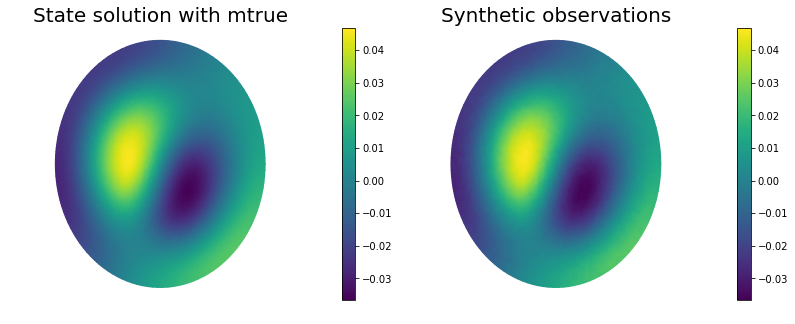

In [6]:
# noise level
noise_level = 0.01

forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(mtrue)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(mtrue) * u_inc * u_test * ufl.dx

# solve the forward/state problem to generate synthetic observations
bc_state = []
forward_lhsa, forward_rhsa = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)

utrue = dl.Function(Vu)
dl.solve(forward_lhsa, utrue.vector(), forward_rhsa)

d = dl.Function(Vu)
d.assign(utrue)

# perturb state solution and create synthetic measurements d
# d = u + ||u||/SNR * random.normal
MAX = d.vector().norm("linf")
noise = dl.Vector()
forward_lhsa.init_vector(noise,1)
noise.set_local( noise_level * MAX * np.random.normal(0, 1, len(d.vector().get_local())) )

d.vector().axpy(1., noise)

# plot
nb.multi1_plot([utrue, d], ["State solution with mtrue", "Synthetic observations"])
plt.show()

Our cost function is as follows:

\begin{gather*}
  \min\limits_{m} \Phi (m) := \frac{1}{2}
  \int_\Gamma (u(m) - d)^2 \; ds
  + \frac{\beta}{2} \int_\Omega {\lVert \nabla m \rVert}^2 \; d\vec{x} \\
\end{gather*}


In [7]:
# Regularization parameter
gamma = 1e-9
beta = gamma

# Define cost function
def cost(u, d, m, gamma):
    misfit = 0.5 * dl.assemble( (u-d)**2*ufl.ds)
    reg = 0.5*gamma * dl.assemble( ufl.inner(dl.grad(m), ufl.grad(m))*ufl.dx ) 
    return [misfit + reg, misfit, reg]

In [8]:
# set up dirichlet boundary conditions
def boundary(x,on_boundary):
    return on_boundary

bc_state = dl.DirichletBC(Vu, dl.Constant(0.), boundary)
bc_adj   = dl.DirichletBC(Vu, dl.Constant(0.), boundary)

Our forward equation in weak form. We covered this earlier, but we are redefining with $m$ instead of $m_{\text{true}}$

\begin{gather*}
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


In [9]:
# We defined this earlier, but now we define with variable m, not m_true.
# Given m, solve for u.
forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(m)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(m) * u_inc * u_test * ufl.dx


The first variation of the Lagrangian with respect to $u$ gives us the weak form of the adjoint equation:

\begin{gather*}
  (\mathcal{L}_u(u,m,p), \tilde{u}) :=
  \int_\Gamma (u - d) \tilde{u} \; d\vec{s}
  + \int_\Omega \nabla \tilde{u} \nabla p
  - (1 - \tanh(m)) \tilde{u} p
  \; d\vec{x}, \quad \forall \tilde{u} \in \mathcal{V} \\
\end{gather*}


In [10]:
# Given m, u, solve for adjoint p
adjoint_eq = ufl.inner(u-d, p_test) * ufl.ds \
    + ufl.inner(ufl.grad(p_test), ufl.grad(p_trial)) * ufl.dx \
    - ufl.inner(1 - ufl.tanh(m), ufl.inner(p_test, p_trial)) * ufl.dx

The first variation of the Lagrangian with respect to $m$ gives us the weak form of the gradient of the objective when we use the corresponding $u,p$ from the state equation and adjoint equation:

\begin{gather*}
  (\mathcal{L}_m(u,m,p), \tilde{m}) :=
  \int_\Omega \beta \nabla m \nabla \tilde{m} \; d\vec{x}
  + \int_\Omega \tilde{m} \frac{1}{\cosh^2(m)} \mathop{\text{sech}}^2(m) \cdot u p \; d\vec{x}
  + \int_\Omega k_0^2 \tilde{m} \frac{1}{\cosh^2(m)} \cdot u^{\text{inc}} p \; d\vec{x}
  , \quad \forall \tilde{m} \in \mathcal{M} \\
\end{gather*}

In [11]:
# Given m, u, p, solve for adjoint p
grad_reg = dl.Constant(beta) * ufl.inner(ufl.grad(m), ufl.grad(m_test)) * ufl.dx
grad_misfit = ufl.inner(m_test / ufl.cosh(m) / ufl.cosh(m) * u, p) * ufl.dx \
    + k0sq * ufl.inner(m_test / ufl.cosh(m) / ufl.cosh(m) * u_inc, p) * ufl.dx


### Finite difference check of the gradient

We use a **finite difference check** to verify that our gradient derivation is correct.
Specifically, we consider a function $ m_0\in \mathcal{M}$ and we verify that for an arbitrary direction $\tilde{m} \in \mathcal{M}$ we have
$$ r := \left| \frac{ \mathcal{J}(m_0 + \varepsilon \tilde{m}) - \mathcal{J}(m_0)}{\varepsilon} -  \left(\mathcal{G}(m_0), \tilde{m}\right)\right| = \mathcal{O}(\varepsilon).$$

In the figure below we show in a loglog scale the value of $r$ as a function of $\varepsilon$. We observe that $r$ decays linearly for a wide range of values of $\varepsilon$, however we notice an increase in the error for extremely small values of $\varepsilon$ due to numerical stability and finite precision arithmetic.


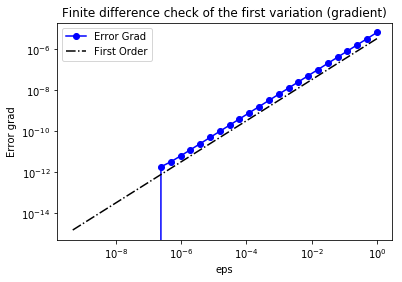

In [12]:
m0 = dl.interpolate(dl.Constant(np.log(4.) ), Vm )

n_eps = 32
eps = np.power(2., -np.arange(n_eps))
err_grad = np.zeros(n_eps)

m.assign(m0)

# Solve the fwd problem and evaluate the cost functional
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)

c0, _, _ = cost(u, d, m, gamma)

# Solve the adjoint problem and evaluate the gradient
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)

# evaluate the  gradient
grad0 = dl.assemble(grad_misfit + grad_reg)

# Define an arbitrary direction m_hat to perform the check 
mtilde = dl.Function(Vm).vector()
mtilde.set_local(np.random.randn(Vm.dim()))
mtilde.apply("")
mtilde_grad0 = grad0.inner(mtilde)

for i in range(n_eps):
    m.assign(m0)
    m.vector().axpy(eps[i], mtilde)
    
    A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
    dl.solve(A, u.vector(), state_b)

    cplus, _, _ = cost(u, d, m, gamma)
   
    err_grad[i] = abs( (cplus - c0)/eps[i] - mtilde_grad0 )

plt.figure()    
plt.loglog(eps, err_grad, "-ob", label="Error Grad")
plt.loglog(eps, (.5*err_grad[0]/eps[0])*eps, "-.k", label="First Order")
plt.title("Finite difference check of the first variation (gradient)")
plt.xlabel("eps")
plt.ylabel("Error grad")
plt.legend(loc = "upper left")
plt.show()

### Initial guess

We solve the state equation and compute the cost functional for the initial guess of the parameter ``m0``

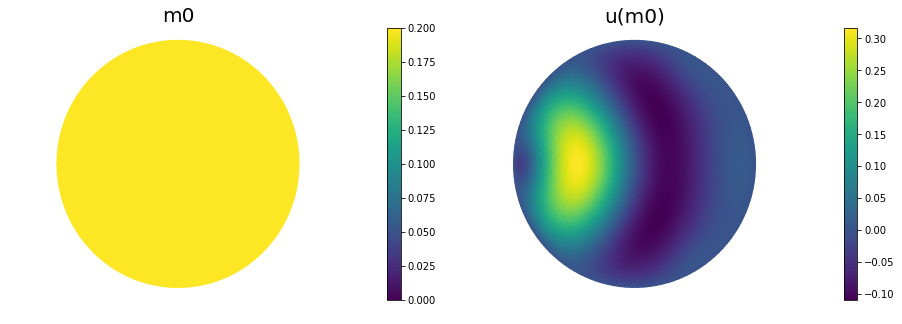

In [13]:
m.assign(m0)

# solve state equation
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)

# evaluate cost
[cost_old, misfit_old, reg_old] = cost(u, d, m, gamma)

# plot
plt.figure(figsize=(15,5))
nb.plot(m,subplot_loc=121, mytitle="m0", vmin=mtrue.vector().min(), vmax=mtrue.vector().max())
nb.plot(u,subplot_loc=122, mytitle="u(m0)")
plt.show()

## The steepest descent with Armijo line search:

We solve the constrained optimization problem using the steepest descent method with Armijo line search.

The stopping criterion is based on a relative reduction of the norm of the gradient (i.e. $\frac{\|g_{n}\|}{\|g_{0}\|} \leq \tau$).

The gradient is computed by solving the state and adjoint equation for the current parameter $m$, and then substituing the current state $u$, parameter $m$ and adjoint $p$ variables in the weak form expression of the gradient:

$$ (g, \tilde{m}) = \gamma(\nabla m, \nabla \tilde{m}) +(\tilde{m}e^m\nabla u, \nabla p).$$

Note that to obtain the expansion coefficient of the gradient $g$ in the finite element basis, we need to solve a linear system, where the left-hand side matrix is a mass matrix (stemming from finite element discretization of the $L^2$-inner product. In practice, we can also precondition the gradient descent direction by use of any symmetric positive definite operator $P$. For example, we can take $P$ as the finite element matrix stemming from discretization of the $H^1$-inner product.

The Armijo line search uses backtracking to find $\alpha$ such that a sufficient reduction in the cost functional is achieved.
Specifically, we use backtracking to find $\alpha$ such that:

$$J( m - \alpha g ) \leq J(m) - \alpha c_{\rm armijo} (g,g). $$


In [14]:
# Mass matrix in parameter space
Mvarf    = ufl.inner(m_trial, m_test) * ufl.dx
M = dl.assemble(Mvarf)

#  matrix in parameter space
Kvarf    = ufl.inner(m_trial, m_test) * ufl.dx + ufl.inner(ufl.grad(m_trial), ufl.grad(m_test)) * ufl.dx
K = dl.assemble(Kvarf)

In [15]:
# define parameters for the optimization
tol = 1e-4         # Relative tolerance on the gradient norm
maxiter = 1000     # Maximum number of iterations (we need a lot!)
print_any = 10     # We will only print progress on screen every few iterations
plot_any = 50      # We will plot the current solution every few iterations
c_armijo = 1e-5    # The Armijo constant to ensure sufficient descent
alpha = 1.e5       # The initial step-size

# initialize iter counters
iter = 0
converged = False

# initializations
g = dl.Vector()
M.init_vector(g,0)

m_prev = dl.Function(Vm)

#Select whether to use the L^2 inner product (mass matrix M)
# or to precondition steepest descent using the H^1 inner product (stiffness matrix K)
P = M

print( "Nit  cost          misfit        reg         ||grad||       alpha  N backtrack" )

while iter <  maxiter and not converged:

    # solve the adoint problem
    adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
    dl.solve(adj_A, p.vector(), adjoint_RHS)

    # evaluate the  gradient
    MG = dl.assemble(grad_misfit + grad_reg)
    dl.solve(P, g, MG)

    # calculate the norm of the gradient
    grad_norm2 = g.inner(MG)
    gradnorm = np.sqrt(grad_norm2)
    
    if iter == 0:
        gradnorm0 = gradnorm

    # linesearch
    it_backtrack = 0
    m_prev.assign(m)
    backtrack_converged = False
    for it_backtrack in range(20):
        
        m.vector().axpy(-alpha, g )

        # solve the forward problem
        state_A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
        dl.solve(state_A, u.vector(), state_b)

        # evaluate cost
        [cost_new, misfit_new, reg_new] = cost(u, d, m, gamma)

        # check if Armijo conditions are satisfied
        if cost_new < cost_old - alpha * c_armijo * grad_norm2:
            cost_old = cost_new
            backtrack_converged = True
            break
        else:
            alpha *= 0.5
            m.assign(m_prev)  # reset m
            
    if backtrack_converged == False:
        print( "Backtracking failed. A sufficient descent direction was not found" )
        converged = False
        break

    sp = ""
    if (iter % print_any)== 0 :
        print( "%3d %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %3d" % \
            (iter, sp, cost_new, sp, misfit_new, sp, reg_new, sp, \
            gradnorm, sp, alpha, sp, it_backtrack) )

    if (iter % plot_any)== 0 :
        nb.multi1_plot([m,u,p], ["m","u","p"], same_colorbar=False)
        plt.show()
    
    # check for convergence
    if gradnorm < tol*gradnorm0 and iter > 0:
        converged = True
        print ("Steepest descent converged in ",iter,"  iterations")
    
    alpha *= 1.5    # Try to increase the step size for the next iteration
    iter += 1
    
if not converged:
    print ( "Steepest descent did not converge in ", maxiter, " iterations")

Nit  cost          misfit        reg         ||grad||       alpha  N backtrack
Backtracking failed. A sufficient descent direction was not found
Steepest descent did not converge in  1000  iterations
